# Building Real - World Mini AI/ML Project

# 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 2. Load Dataset

In [3]:
df = pd.read_csv("dataset/raw_dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 12


# 3. Data Understanding

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 4. Identify Missing Values, Detect Outliers and Incorrect Data types

In [16]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [10]:
print(df.duplicated().sum())

0


In [11]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


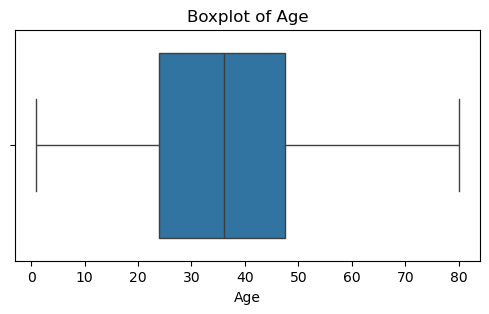

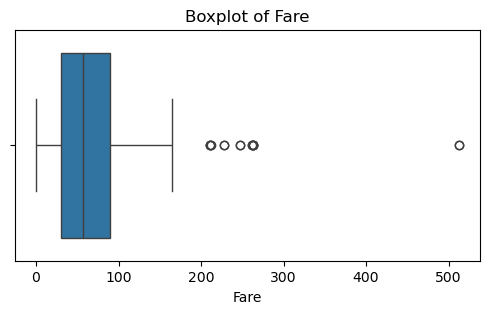

In [17]:
num_cols = ['Age','Fare']
for col in num_cols:
    
    plt.figure(figsize=(6,3))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

# 5. Data Cleaning

In [19]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [20]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

# 6. Exploratory Data Analysis(EDA)

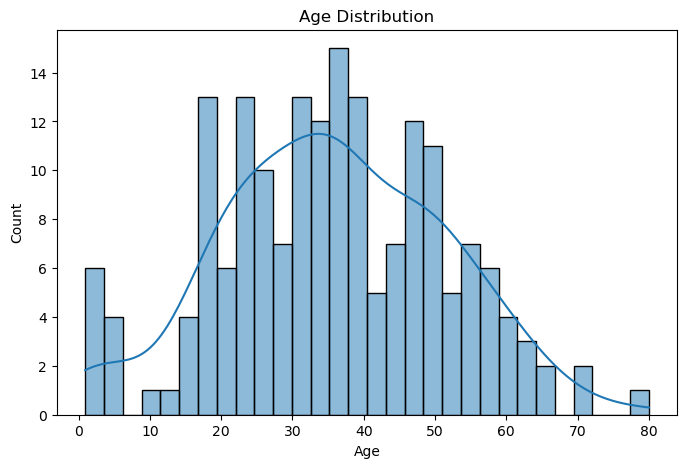

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

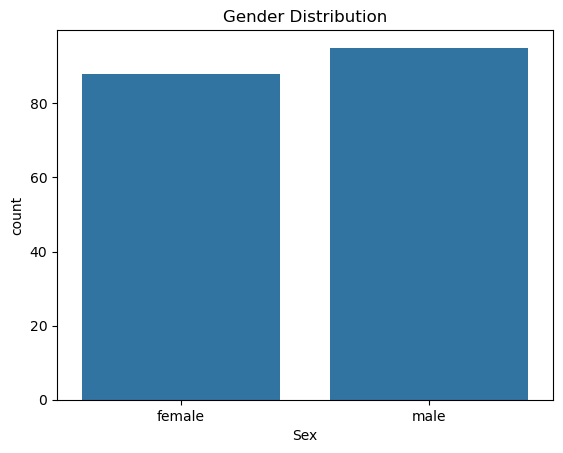

In [22]:
sns.countplot(x='Sex', data=df)

plt.title("Gender Distribution")

plt.show()

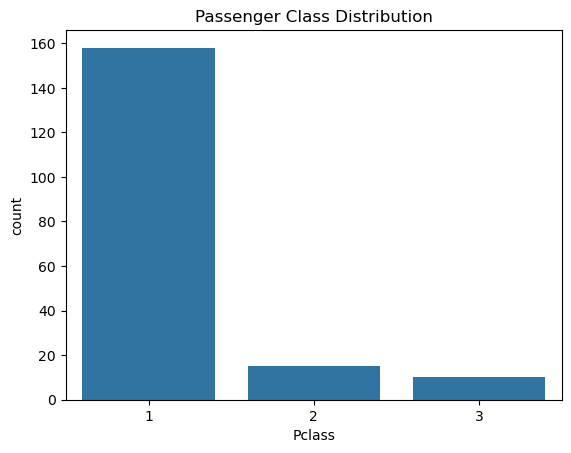

In [23]:
sns.countplot(x='Pclass', data=df)

plt.title("Passenger Class Distribution")

plt.show()

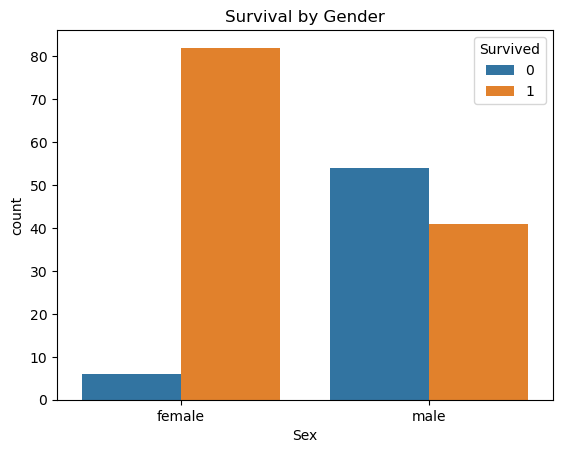

In [24]:
sns.countplot(x='Sex',
              hue='Survived',
              data=df)

plt.title("Survival by Gender")

plt.show()

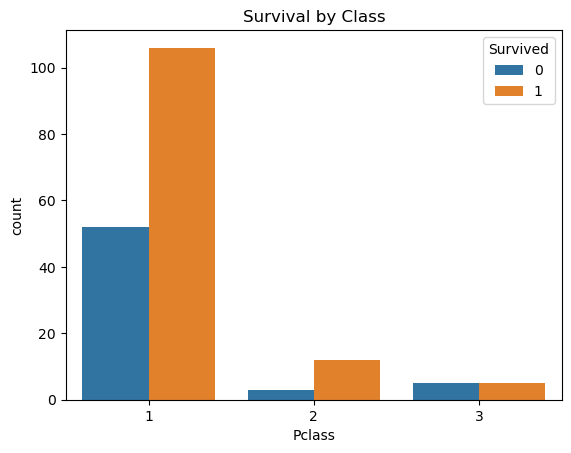

In [25]:
sns.countplot(x='Pclass',
              hue='Survived',
              data=df)

plt.title("Survival by Class")

plt.show()

In [26]:
temp_df = df.copy()

temp_df['Sex'] = temp_df['Sex'].map({'male':0,'female':1})

temp_df['Embarked'] = temp_df['Embarked'].map(
    {'S':0,'C':1,'Q':2}
)

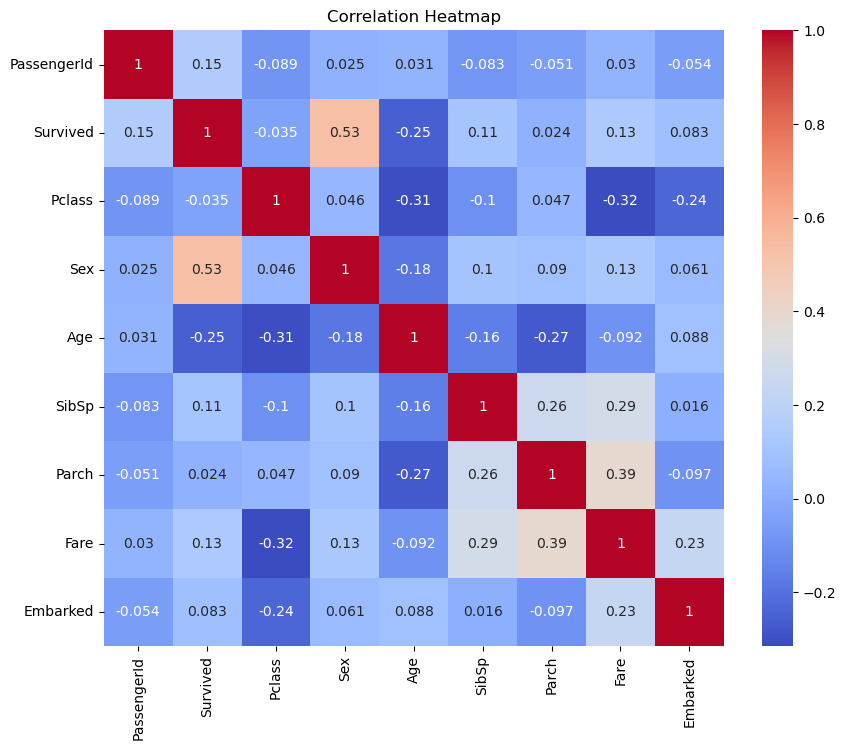

In [27]:
plt.figure(figsize=(10,8))

sns.heatmap(
    temp_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# 7. Feature Engineering

In [28]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [29]:
df['IsAlone'] = 0

df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

In [30]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,12,19,35,60,100],
    labels=['Child',
            'Teen',
            'YoungAdult',
            'Adult',
            'Senior']
)

# 8. Encode Categorical Features

In [31]:
encoder = LabelEncoder()

In [32]:
df['Sex'] = encoder.fit_transform(df['Sex'])
df['Embarked'] = encoder.fit_transform(df['Embarked'])
df['AgeGroup'] = encoder.fit_transform(df['AgeGroup'])

In [33]:
df.drop(
    columns=[
        'PassengerId',
        'Name',
        'Ticket'
    ],
    inplace=True
)

# 9. Feature Scaling

In [35]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

ValueError: could not convert string to float: 'C85'

In [36]:
print(X.select_dtypes(include='object').columns)

Index(['Cabin'], dtype='object')


In [37]:
df.drop('Cabin', axis=1, inplace=True)

In [38]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [39]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [40]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

In [41]:
print(X_scaled.head())

     Pclass       Sex       Age     SibSp     Parch      Fare  Embarked  \
0 -0.372256 -1.039012  0.149065  0.833628 -0.631730 -0.097180 -1.339397   
1 -0.372256 -1.039012 -0.043230  0.833628 -0.631730 -0.335997  0.755557   
2 -0.372256  0.962453  1.174636 -0.723044 -0.631730 -0.352250  0.755557   
3  3.520480 -1.039012 -2.030273  0.833628  0.697081 -0.814070  0.755557   
4 -0.372256 -1.039012  1.431029 -0.723044 -0.631730 -0.684702  0.755557   

   FamilySize   IsAlone  AgeGroup  
0    0.054289 -0.871559 -0.994934  
1    0.054289 -0.871559  1.218719  
2   -0.848889  1.147369 -0.994934  
3    0.957467 -0.871559 -0.441521  
4   -0.848889  1.147369 -0.994934  


# 10. Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (146, 10)
Testing Shape: (37, 10)


# 11. Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

# 12. Decision Tree

In [44]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

# 13. Model Evaluation

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# (a) Evaluation for Logistic Regression algorithm

In [46]:
print("LOGISTIC REGRESSION RESULTS\n")

print("Accuracy :", accuracy_score(y_test, lr_pred))

print("Precision:", precision_score(y_test, lr_pred))

print("Recall   :", recall_score(y_test, lr_pred))

print("F1 Score :", f1_score(y_test, lr_pred))

LOGISTIC REGRESSION RESULTS

Accuracy : 0.7297297297297297
Precision: 0.7777777777777778
Recall   : 0.84
F1 Score : 0.8076923076923077


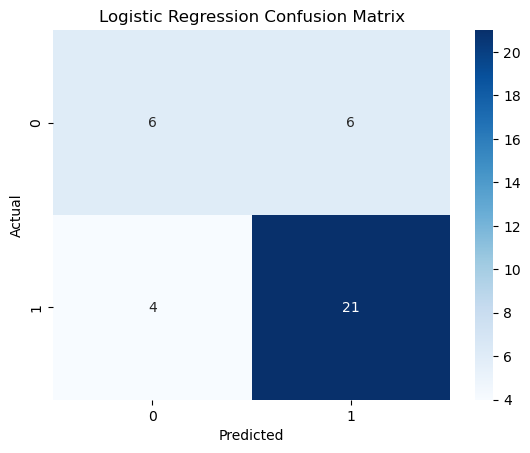

In [47]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# (b) Evaluation for Decision Tree Algorithm

In [48]:
print("DECISION TREE RESULTS\n")

print("Accuracy :", accuracy_score(y_test, dt_pred))

print("Precision:", precision_score(y_test, dt_pred))

print("Recall   :", recall_score(y_test, dt_pred))

print("F1 Score :", f1_score(y_test, dt_pred))

DECISION TREE RESULTS

Accuracy : 0.7297297297297297
Precision: 0.8
Recall   : 0.8
F1 Score : 0.8


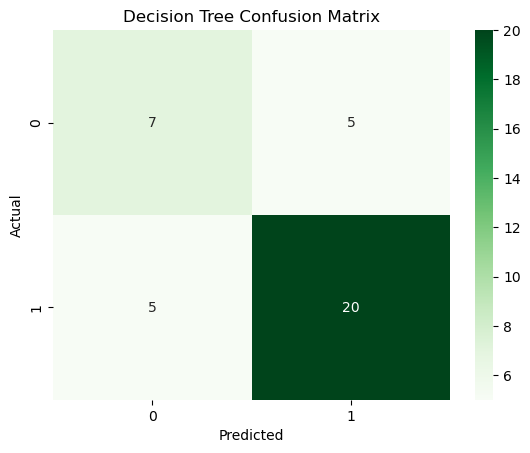

In [49]:
cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# 14. Model Comparison

In [50]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.72973,0.777778,0.84,0.807692
1,Decision Tree,0.72973,0.800000,0.80,0.800000


# 15. Hyperparameter Tuning

In [51]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3,5,7,10,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

In [53]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [54]:
best_dt = grid_search.best_estimator_

best_pred = best_dt.predict(X_test)

print(
    "Tuned Accuracy:",
    accuracy_score(y_test, best_pred)
)

Tuned Accuracy: 0.7027027027027027


# 16. Cross Validation

# (a) Logistic Regression

In [55]:
from sklearn.model_selection import cross_val_score

lr_scores = cross_val_score(
    lr_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("Logistic Regression CV Scores:")

print(lr_scores)

print("Mean Accuracy:")

print(lr_scores.mean())

Logistic Regression CV Scores:
[0.72972973 0.81081081 0.7027027  0.63888889 0.77777778]
Mean Accuracy:
0.7319819819819819


# (b) Decision Tree

In [56]:
dt_scores = cross_val_score(
    dt_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("Decision Tree CV Scores:")

print(dt_scores)

print("Mean Accuracy:")

print(dt_scores.mean())

Decision Tree CV Scores:
[0.81081081 0.89189189 0.75675676 0.61111111 0.83333333]
Mean Accuracy:
0.7807807807807808


# 17. Visualization of Feature Importance

In [57]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
2,Age,0.375762
1,Sex,0.354051
5,Fare,0.160046
9,AgeGroup,0.069532
3,SibSp,0.040610
0,Pclass,0.000000
4,Parch,0.000000
6,Embarked,0.000000
7,FamilySize,0.000000
8,IsAlone,0.000000


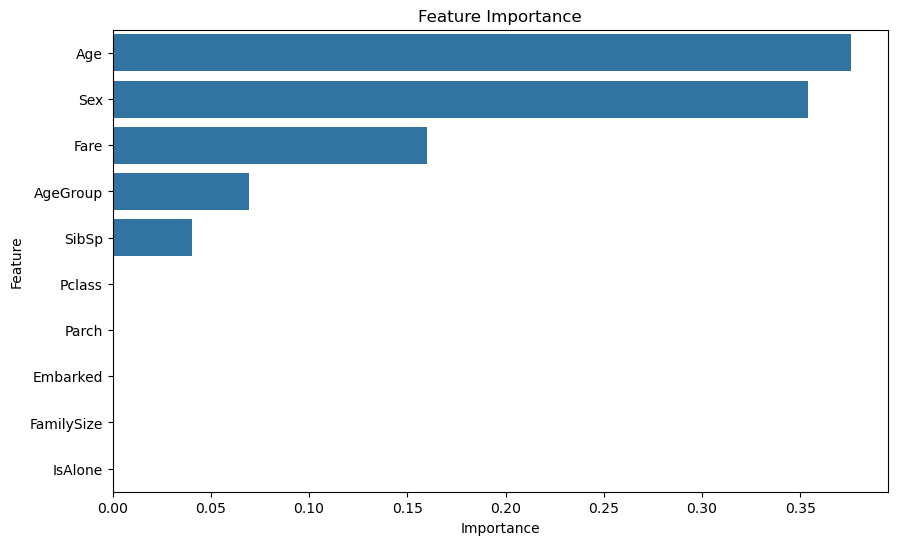

In [58]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

In [59]:
df.to_csv("cleaned_dataset.csv", index=False)